# Import libraries

In [2]:
import pandas as pd
!pip install pandas pyarrow

# Import data

In [3]:
taxi_data = pd.read_parquet(r"C:\Users\HP\Desktop\new-york-taxi-analysis\data\yellow_tripdata_2019-01.parquet")
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [4]:
taxi_data.shape

(7696617, 19)

# Data exploration

In [5]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [6]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID','PULocationID',
       'DOLocationID', 'payment_type',  'total_amount']]

array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>]], dtype=object)

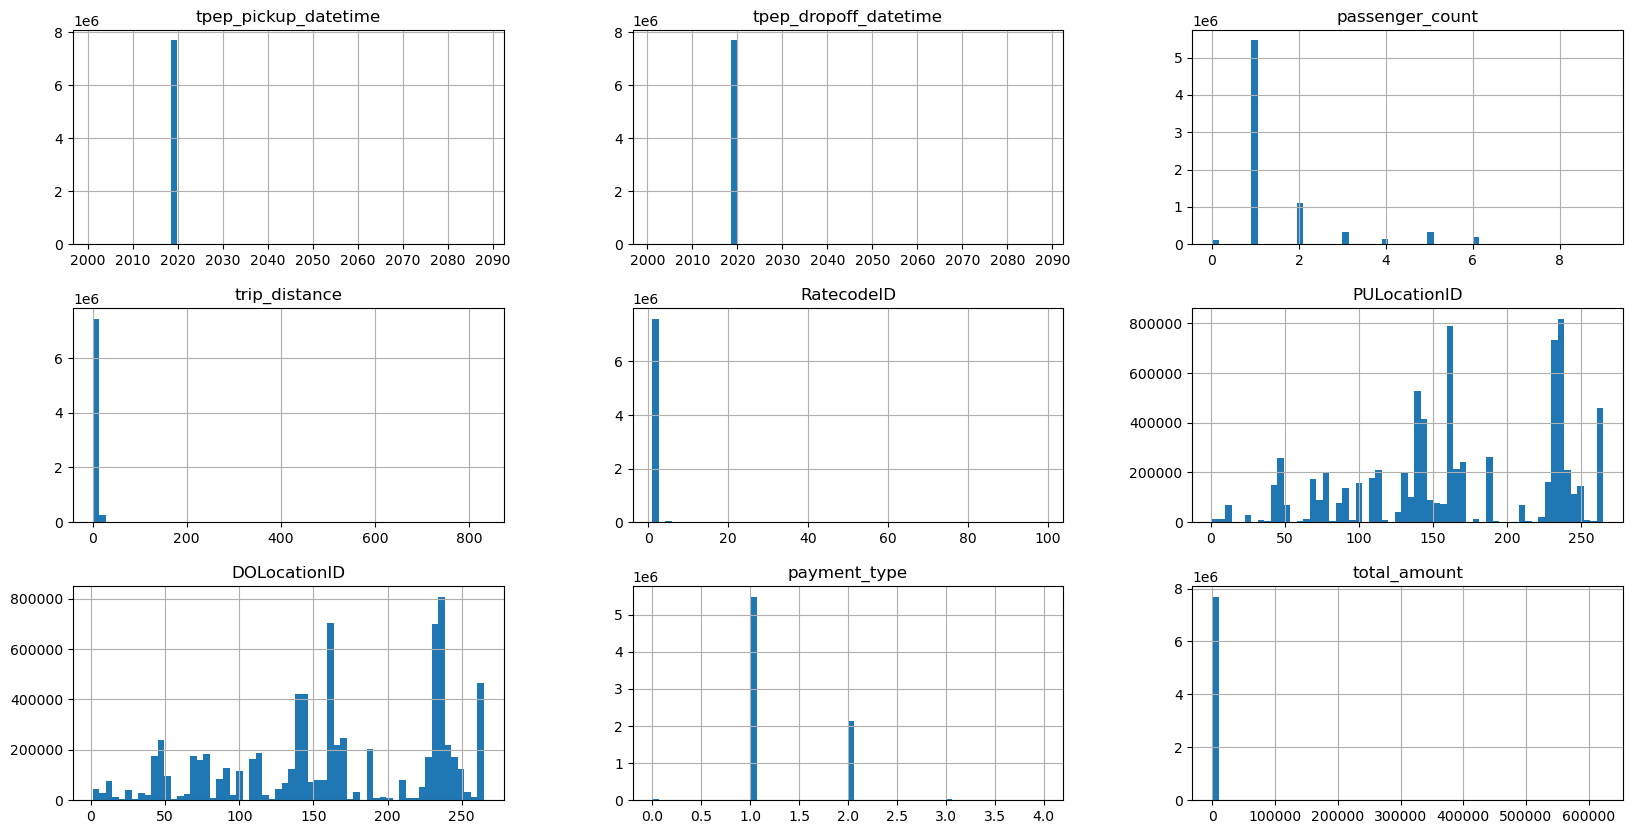

In [7]:
taxi_data.hist(figsize=(20,10), bins=60)

In [8]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

<Axes: xlabel='index', ylabel='total_amount'>

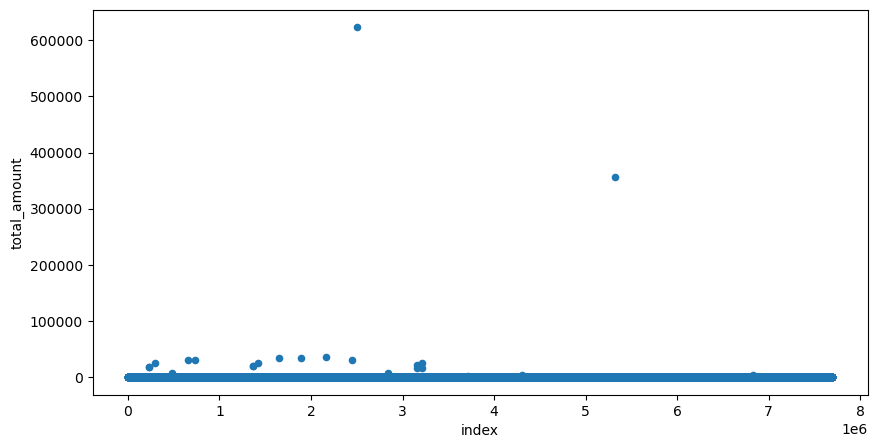

In [9]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

<Axes: xlabel='index', ylabel='total_amount'>

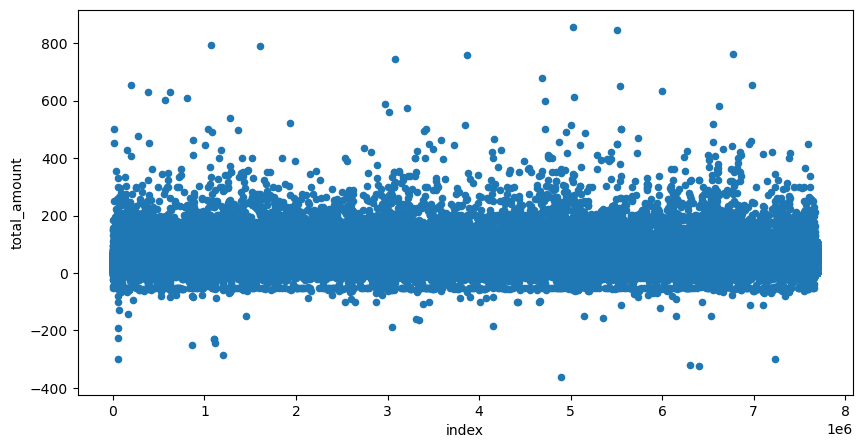

In [10]:
taxi_data[taxi_data['total_amount']<1000].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

### Two things to deal with: negative values and very high values. Let's first look at negative values.

(7127, 9)


<Axes: xlabel='index', ylabel='total_amount'>

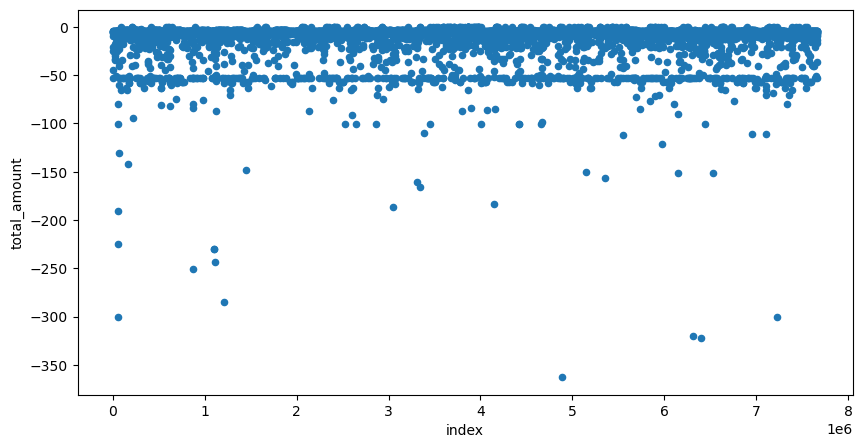

In [11]:
print(taxi_data[taxi_data['total_amount']<0].shape)
taxi_data[taxi_data['total_amount']<0].reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [12]:
taxi_data[taxi_data['total_amount']<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3


In [13]:
taxi_data[taxi_data['total_amount']<0]['payment_type'].value_counts()

payment_type
3    4083
4    2667
2     376
1       1
Name: count, dtype: int64

<Axes: >

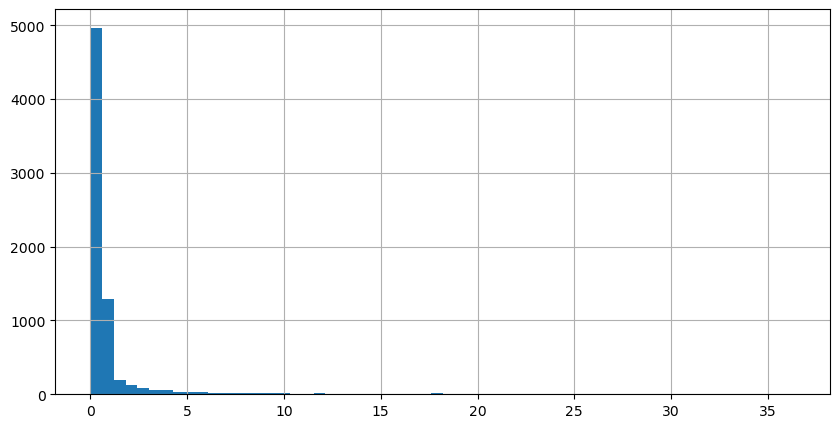

In [14]:
taxi_data[taxi_data['total_amount']<0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [15]:
print(taxi_data[taxi_data['total_amount']==0].shape)
taxi_data[taxi_data['total_amount']==0].head()

(1643, 9)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,186,264,2,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,246,264,2,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,193,193,1,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1.0,0.0,1.0,7,7,2,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1.0,0.0,1.0,264,7,2,0.0


In [16]:
taxi_data[taxi_data['total_amount']==0]['payment_type'].value_counts()

payment_type
1    813
2    569
0    231
3     29
4      1
Name: count, dtype: int64

<Axes: >

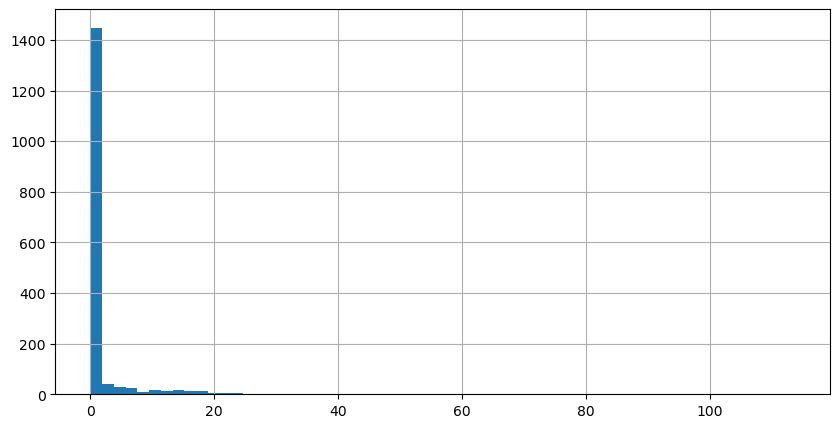

In [17]:
taxi_data[taxi_data['total_amount']==0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [18]:
taxi_data[taxi_data['total_amount']==0]['trip_distance'].value_counts()

trip_distance
0.00     1323
0.03        9
0.01        8
0.06        6
1.00        4
         ... 
11.86       1
4.59        1
20.92       1
18.37       1
12.30       1
Name: count, Length: 256, dtype: int64

### We can safely get rid of the negative values. What about the very high values?

<Axes: xlabel='index', ylabel='total_amount'>

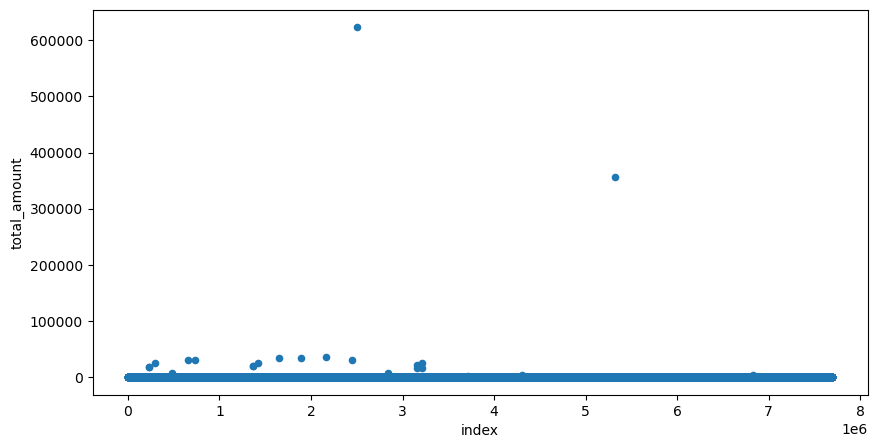

In [19]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [23]:
taxi_data[taxi_data['total_amount']>200].shape


(1166, 9)

In [24]:
taxi_data['total_amount'].mean()

np.float64(15.810651344610237)

### We can agree to cut from $200 level.

In [26]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount']>=0)&(taxi_data['total_amount']<200)]

In [27]:
print(taxi_data.shape)
taxi_data_filtered.shape

(7696617, 9)


(7688319, 9)

### Any missing values?

<Axes: xlabel='index', ylabel='total_amount'>

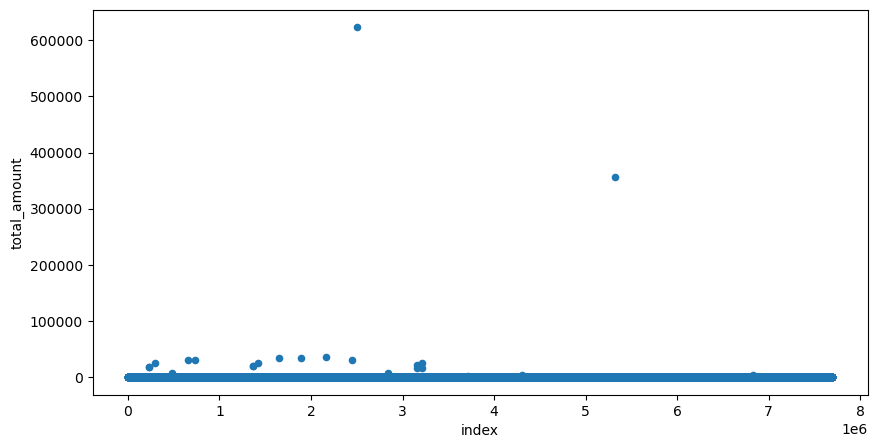

In [29]:
taxi_data.reset_index().plot(kind='scatter', y='total_amount', x='index', figsize=(10,5))

In [30]:
taxi_data[taxi_data['passenger_count']<=0]['RatecodeID'].value_counts()
taxi_data_filtered[
    (taxi_data_filtered['passenger_count'] == 0)
]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
156,2019-01-01 00:32:24,2019-01-01 00:33:21,0.0,5.3,1.0,50,50,1,4.55
228,2019-01-01 00:00:50,2019-01-01 00:31:48,0.0,18.0,2.0,132,140,1,59.80
229,2019-01-01 00:38:32,2019-01-01 01:09:51,0.0,8.9,1.0,229,37,1,38.50
298,2019-01-01 00:45:19,2019-01-01 00:55:53,0.0,1.0,1.0,107,170,2,9.30
905,2019-01-01 00:20:15,2019-01-01 00:26:42,0.0,0.7,1.0,90,249,1,8.30
...,...,...,...,...,...,...,...,...,...
7667705,2019-01-31 23:56:07,2019-02-01 00:13:46,0.0,2.8,1.0,264,264,1,16.30
7667734,2019-01-31 23:36:42,2019-01-31 23:57:43,0.0,4.8,1.0,161,13,1,20.80
7667765,2019-01-31 23:06:23,2019-01-31 23:18:20,0.0,3.2,1.0,68,239,1,15.95
7667917,2019-01-31 23:06:51,2019-01-31 23:15:06,0.0,1.4,1.0,162,186,2,8.80


In [31]:
taxi_data_filtered['passenger_count'].value_counts()
taxi_data_filtered = taxi_data_filtered[
    ~taxi_data_filtered['passenger_count'].isin([6, 7, 8, 9])
]
taxi_data_filtered['passenger_count'].value_counts()

passenger_count
1.0    5450602
2.0    1112657
5.0     323448
3.0     314333
4.0     140626
0.0     117310
Name: count, dtype: int64

In [32]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28672
trip_distance                0
RatecodeID               28672
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
dtype: int64

In [33]:
taxi_data_filtered[taxi_data_filtered['passenger_count'].isna()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount
7667945,2019-01-01 00:38:45,2019-01-01 00:54:11,NaN,2.21,NaN,161,263,0,16.30
7667946,2019-01-01 01:56:58,2019-01-01 02:13:14,NaN,3.17,NaN,256,226,0,19.59
7667947,2019-01-01 01:59:06,2019-01-01 02:20:24,NaN,6.31,NaN,140,256,0,34.04
7667948,2019-01-01 02:34:00,2019-01-01 02:34:00,NaN,0.00,NaN,233,233,0,0.00
7667949,2019-01-01 02:44:00,2019-01-01 03:03:00,NaN,11.86,NaN,246,265,0,0.00
...,...,...,...,...,...,...,...,...,...
7696612,2019-01-31 23:37:20,2019-02-01 00:10:43,NaN,10.24,NaN,142,95,0,0.00
7696613,2019-01-31 23:28:00,2019-01-31 23:50:50,NaN,12.43,NaN,48,213,0,54.60
7696614,2019-01-31 23:11:00,2019-01-31 23:46:00,NaN,9.14,NaN,159,246,0,54.60
7696615,2019-01-31 23:03:00,2019-01-31 23:14:00,NaN,0.00,NaN,265,265,0,0.00


In [35]:
taxi_data_filtered = taxi_data.copy()

In [36]:
total_rows = len(taxi_data_filtered)

invalid_rows = (
    taxi_data_filtered['passenger_count'].isna() &
    taxi_data_filtered['RatecodeID'].isna()
).sum()

print("Total rows:", total_rows)
print("Invalid rows:", invalid_rows)
print("Percentage:", invalid_rows / total_rows * 100)


Total rows: 7696617
Invalid rows: 28672
Percentage: 0.37252730647763815


In [37]:
taxi_data_filtered = taxi_data_filtered.dropna(
    subset=['passenger_count', 'RatecodeID'],
    how='all'
)

In [38]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
dtype: int64

# Data Preparation